In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from matplotlib import pyplot as plt
from matplotlib import font_manager

font_dirs = ['/home/miner/fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["mathtext.fontset"] = 'cm'

In [3]:
def get_traj_likelihoods(folder):
    single_traj_likelihoods = pd.read_csv(Path(folder)/'likelihood.csv')

    expanded_id = single_traj_likelihoods['id'].str.rsplit("_",n=1,expand=True)
    
    times = expanded_id[1].astype(float)
    ids = expanded_id[0]
    single_traj_likelihoods['id'] = ids
    single_traj_likelihoods['Timestep'] = times
    single_traj_likelihoods['nll'] = -(single_traj_likelihoods['prior:smax_gaussian'] + single_traj_likelihoods['integrand:TotalIntegrand'])/3
    
    single_traj_likelihoods = single_traj_likelihoods.iloc[::-1,:]

    all_ids = np.unique(ids)

    resdict = {}
    for id in all_ids:
        resdict[id] = single_traj_likelihoods[single_traj_likelihoods['id']==id].reset_index()
        
    return resdict

In [4]:
flow_likelihoods = get_traj_likelihoods(Path('../../likelihood_results/likelihoodv3/dfmdock_tr_3integrand_traj_flow/likelihood.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '../../likelihood_results/likelihoodv3/dfmdock_tr_3integrand_traj_flow/likelihood.csv/likelihood.csv'

In [5]:
# plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, result_2SIC_p30.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, result_2SIC_p90.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p30['Timestep'], result_2SIC_p30.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_2SIC_p90['Timestep'], result_2SIC_p90.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('2SIC_single_traj_likelihood_copy.png', dpi=300, bbox_inches='tight')

NameError: name 'result_2SIC_p30' is not defined

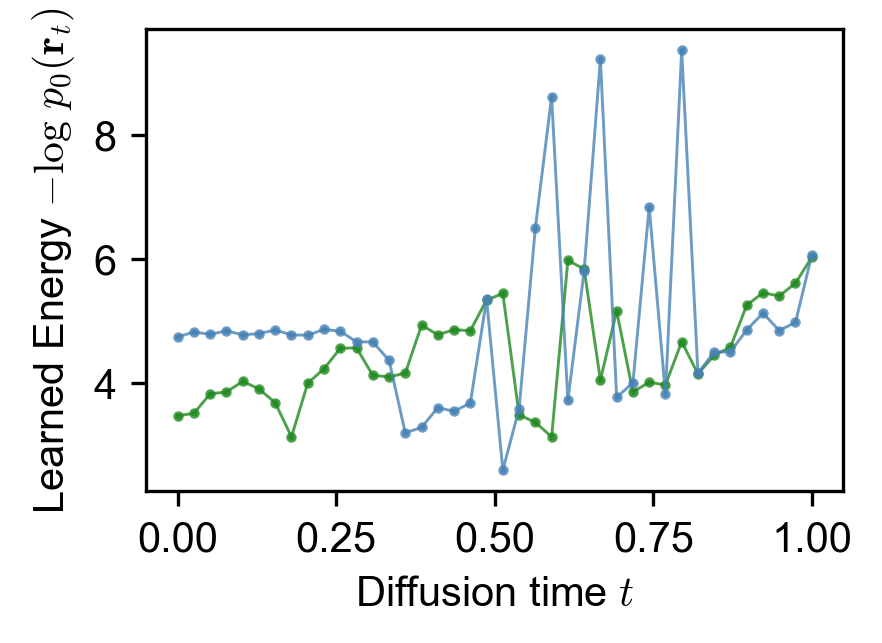

In [24]:
# plt.plot(result_1IRA_p22.index.to_numpy()[::-1]/40, result_1IRA_p22.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_1IRA_p36.index.to_numpy()[::-1]/40, result_1IRA_p36.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p22['Timestep'], result_1IRA_p22.nll, marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
plt.plot(result_1IRA_p36['Timestep'], result_1IRA_p36.nll, marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)


plt.xlabel('Diffusion time $t$')
plt.ylabel(r'Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)
plt.savefig('1IRA_single_traj_likelihood.png', dpi=300, bbox_inches='tight')

# Trajectory Forces

In [8]:
from pathlib import Path
import pandas as pd

def get_forces(forces_folder):
    index = pd.read_csv(forces_folder/'force_index.csv')
    
    cols = ["Offset_Tr_X", "Offset_Tr_Y", "Offset_Tr_Z"]
    score_cols = [f"score"]
    pos_cols = [f"pos"]
    
    traj_force_dict = {}
    for row in index.itertuples():
        id = row.id
        file = row.Forces_CSV
        forcedict = traj_force_dict[id] = {}
        forces = pd.read_csv(Path('..')/file)
        forcedict['id'] = id
        forcedict['time'] = forces['Timestep'].values
        forcedict['score'] = forces[score_cols].values
        forcedict['divergence'] = forces['Divergence']
        forcedict['diff_coeff'] = forces['Diffusion_Coeff']
        forcedict['pos'] = forces[pos_cols].values

    return traj_force_dict

traj_forces = get_forces(Path('../../likelihood_results/likelihoodv3/gaussian_1d/3integrand_traj_forces_25'))
gt_traj_forces = get_forces(Path('../../likelihood_results/likelihoodv3/gaussian_1d/ground_truth/3integrand_traj_forces_25'))


Text(0.5, 1.0, 'Force')

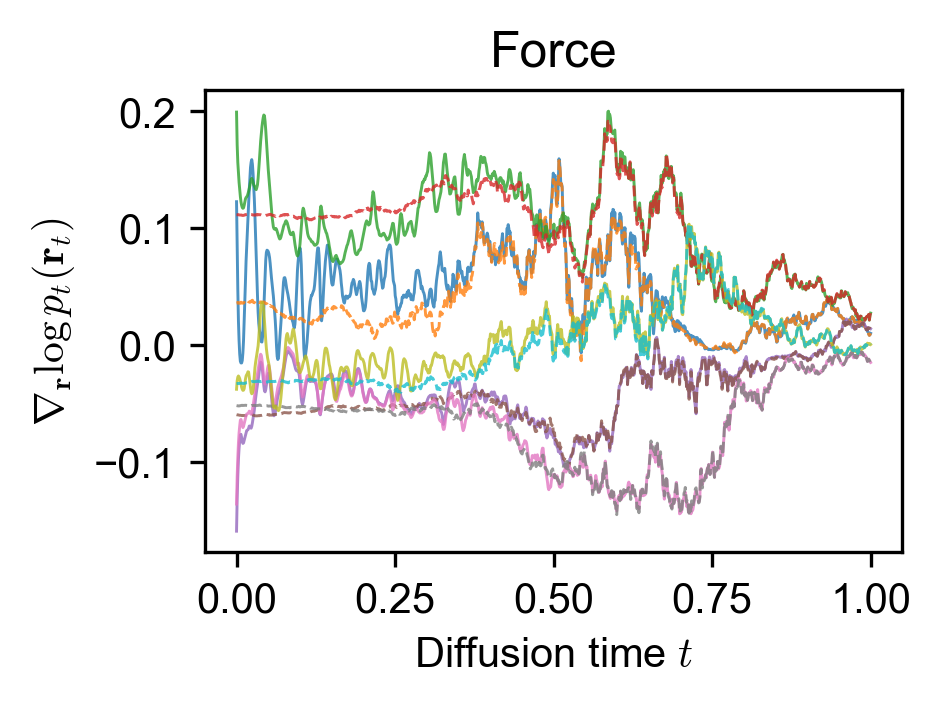

In [11]:
# plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

ids = [1,2,3,4,5]
# cs = ((0.13,0.54,0.13,1.0),(0.28,0.51,0.71,1.0))
for (id,) in zip(ids):
    plt.plot(traj_forces[id]['time'], traj_forces[id]['score'],  linestyle='-', markersize=0.6, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], gt_traj_forces[id]['score'], linestyle='--', markersize=0.6, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p30']['time'], np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title("Force")

Text(0.5, 1.0, 'Scaled Force')

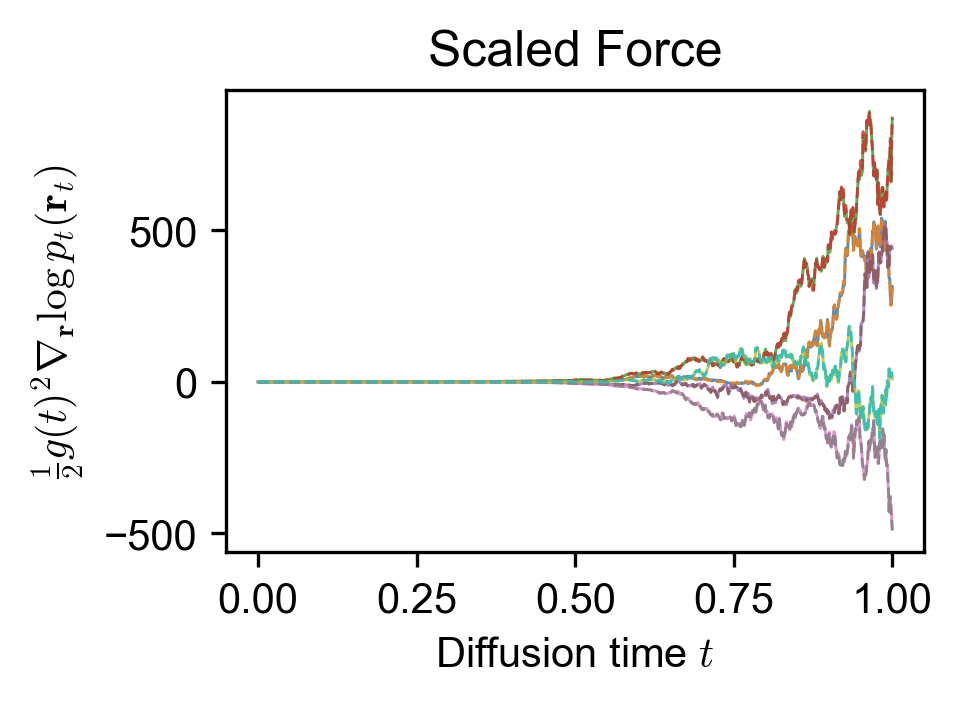

In [30]:
# plt.plot(result_2SIC_p30.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(result_2SIC_p90.index.to_numpy()[::-1]/40, np.linalg.norm(old_traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

ids = [1,2,3,4,5]
# cs = ((0.13,0.54,0.13,1.0),(0.28,0.51,0.71,1.0))
for (id,) in zip(ids):
    plt.plot(traj_forces[id]['time'], 1/2*traj_forces[id]['score'][:,0]*traj_forces[id]['diff_coeff']**2,  linestyle='-', markersize=0.6, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], 1/2*gt_traj_forces[id]['score'][:,0]*gt_traj_forces[id]['diff_coeff']**2, linestyle='--', markersize=0.6, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p30']['time'], np.linalg.norm(traj_force_dict['2SIC_p30']['score'], axis=1), marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], np.linalg.norm(traj_force_dict['2SIC_p90']['score'], axis=1), marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\frac{1}{2}g(t)^2\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title("Scaled Force")

Text(0.5, 1.0, 'Divergence')

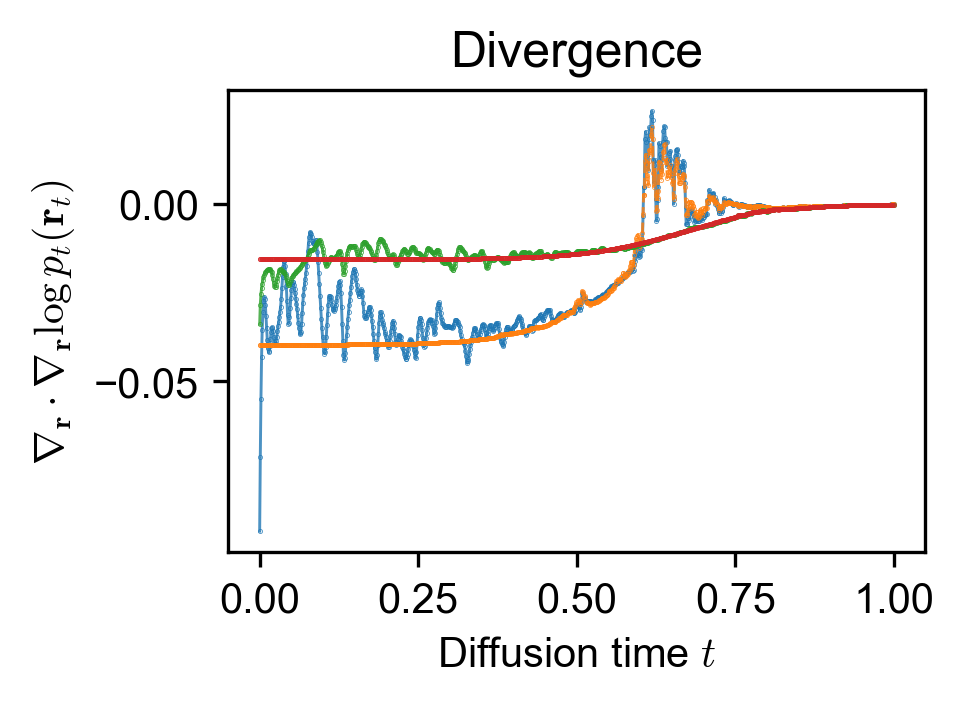

In [31]:
# plt.plot(traj_force_dict['2SIC_p30']['time'], traj_force_dict['2SIC_p30']['divergence], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], traj_force_dict['2SIC_p90']['divergence], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)

for id in (1,2):
    plt.plot(traj_forces[id]['time'], traj_forces[id]['divergence], marker='o', linestyle='-', markersize=0.2, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], gt_traj_forces[id]['divergence], marker='o', linestyle='--', markersize=0.2, alpha=0.8, linewidth=0.7)

plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\nabla_{\mathbf{r}} \cdot \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title('Divergence')

Text(0.5, 1.0, 'Scaled Divergence')

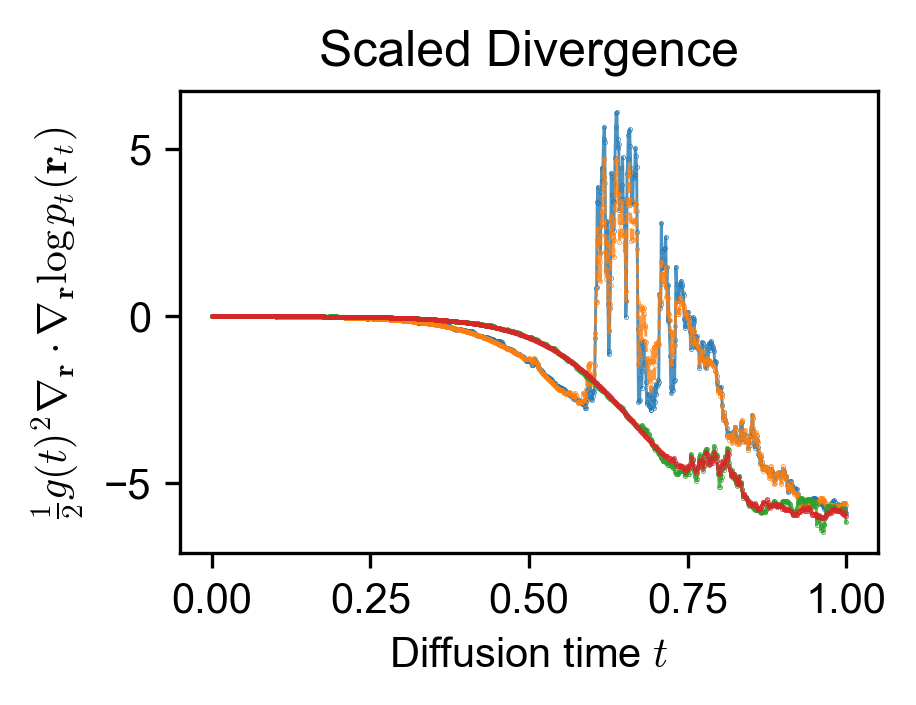

In [32]:
# plt.plot(traj_force_dict['2SIC_p30']['time'], 1/2*traj_force_dict['2SIC_p30']['diff_coeff']**2*traj_force_dict['2SIC_p30']['divergence'], marker='o', linestyle='-', c=(0.13,0.54,0.13,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)
# plt.plot(traj_force_dict['2SIC_p90']['time'], 1/2*traj_force_dict['2SIC_p90']['diff_coeff']**2*traj_force_dict['2SIC_p90']['divergence'], marker='o', linestyle='-', c=(0.28,0.51,0.71,1.0), markersize=1.5, alpha=0.8, linewidth=0.7)


for id in (1,2):
    plt.plot(traj_forces[id]['time'], 1/2*traj_forces[id]['diff_coeff']**2*traj_forces[id]['divergence'], marker='o', linestyle='-', markersize=0.2, alpha=0.8, linewidth=0.7)
    plt.plot(gt_traj_forces[id]['time'], 1/2*gt_traj_forces[id]['diff_coeff']**2*gt_traj_forces[id]['divergence'], marker='o', linestyle='--', markersize=0.2, alpha=0.8, linewidth=0.7)


plt.xlabel('Diffusion time $t$')
plt.ylabel(r'$\frac{1}{2} g(t)^2 \nabla_{\mathbf{r}} \cdot \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
# plt.ylim(2.4, 6.4)
fig = plt.gcf()
fig.set_size_inches(3, 2)
fig.set_dpi(300)

plt.title('Scaled Divergence')

#### Diffusion Energies Figure 4

In [10]:
import pandas as pd
from pathlib import Path
import numpy as np
class TrajectoryIndex:
    def __init__(self,traj_folder:Path,index_file:str|Path):
        self.traj_folder = traj_folder
        self.index_file = traj_folder/index_file
        index_df = pd.read_csv(self.index_file,index_col="index")
        self.files = index_df.to_dict(orient='index')

    def get(self,id:int):
        fname = self.files[id]['filename'] #because of annoying df.to_dict ugh
        traj_df = pd.read_csv(self.traj_folder/fname)
        t = np.array(traj_df['Timestep']); x = np.array(traj_df['Sample'])
        return t,x

    def __getitem__(self,id:int):
        return self.get(id)
        
def get_trajectories(traj_folder:str|Path,index_file:str|Path): return TrajectoryIndex(Path(traj_folder),index_file)

In [11]:
flow_trajectories = get_trajectories('../../likelihood_results/likelihoodv3/gaussian_1d/3integrand_flow/trajectories','trajectory_index.csv')
diff_trajectories = get_trajectories('../../likelihood_results/likelihoodv3/gaussian_1d/3integrand_diff/trajectories','trajectory_index.csv')
difftraj_forces = get_forces(Path('../../likelihood_results/likelihoodv3/gaussian_1d/3integrand_traj_forces_1000'))

In [12]:
from typing import Iterable
from scipy.stats import norm
from diffenergy.helper import int_diffusion_coeff_sq

def get_gaussian(x,means:Iterable,sigmas:Iterable,weights:Iterable):
    return sum([weight*norm.pdf(x,loc=mean,scale=sigma) for (mean,sigma,weight) in zip(means,sigmas,weights)])

def get_gt_gaussian(x,means=[-30.0,0.0,40.0],sigmas=[8.0,5.0,10.0],weights=[0.4,0.3,0.3]):
    return get_gaussian(x,means,sigmas,weights)

def get_timed_gt_gaussian(x,t,means=[-30.0,0.0,40.0],t0_sigmas=[8.0,5.0,10.0],weights=[0.4,0.3,0.3],sigma_min=0.1,sigma_max=70):
    t_sigmas = np.sqrt((np.array(t0_sigmas,dtype=float)**2)[:,None] + int_diffusion_coeff_sq(t,sigma_min=sigma_min,sigma_max=sigma_max).numpy()[None,:])
    return get_gaussian(x,means,t_sigmas,weights)

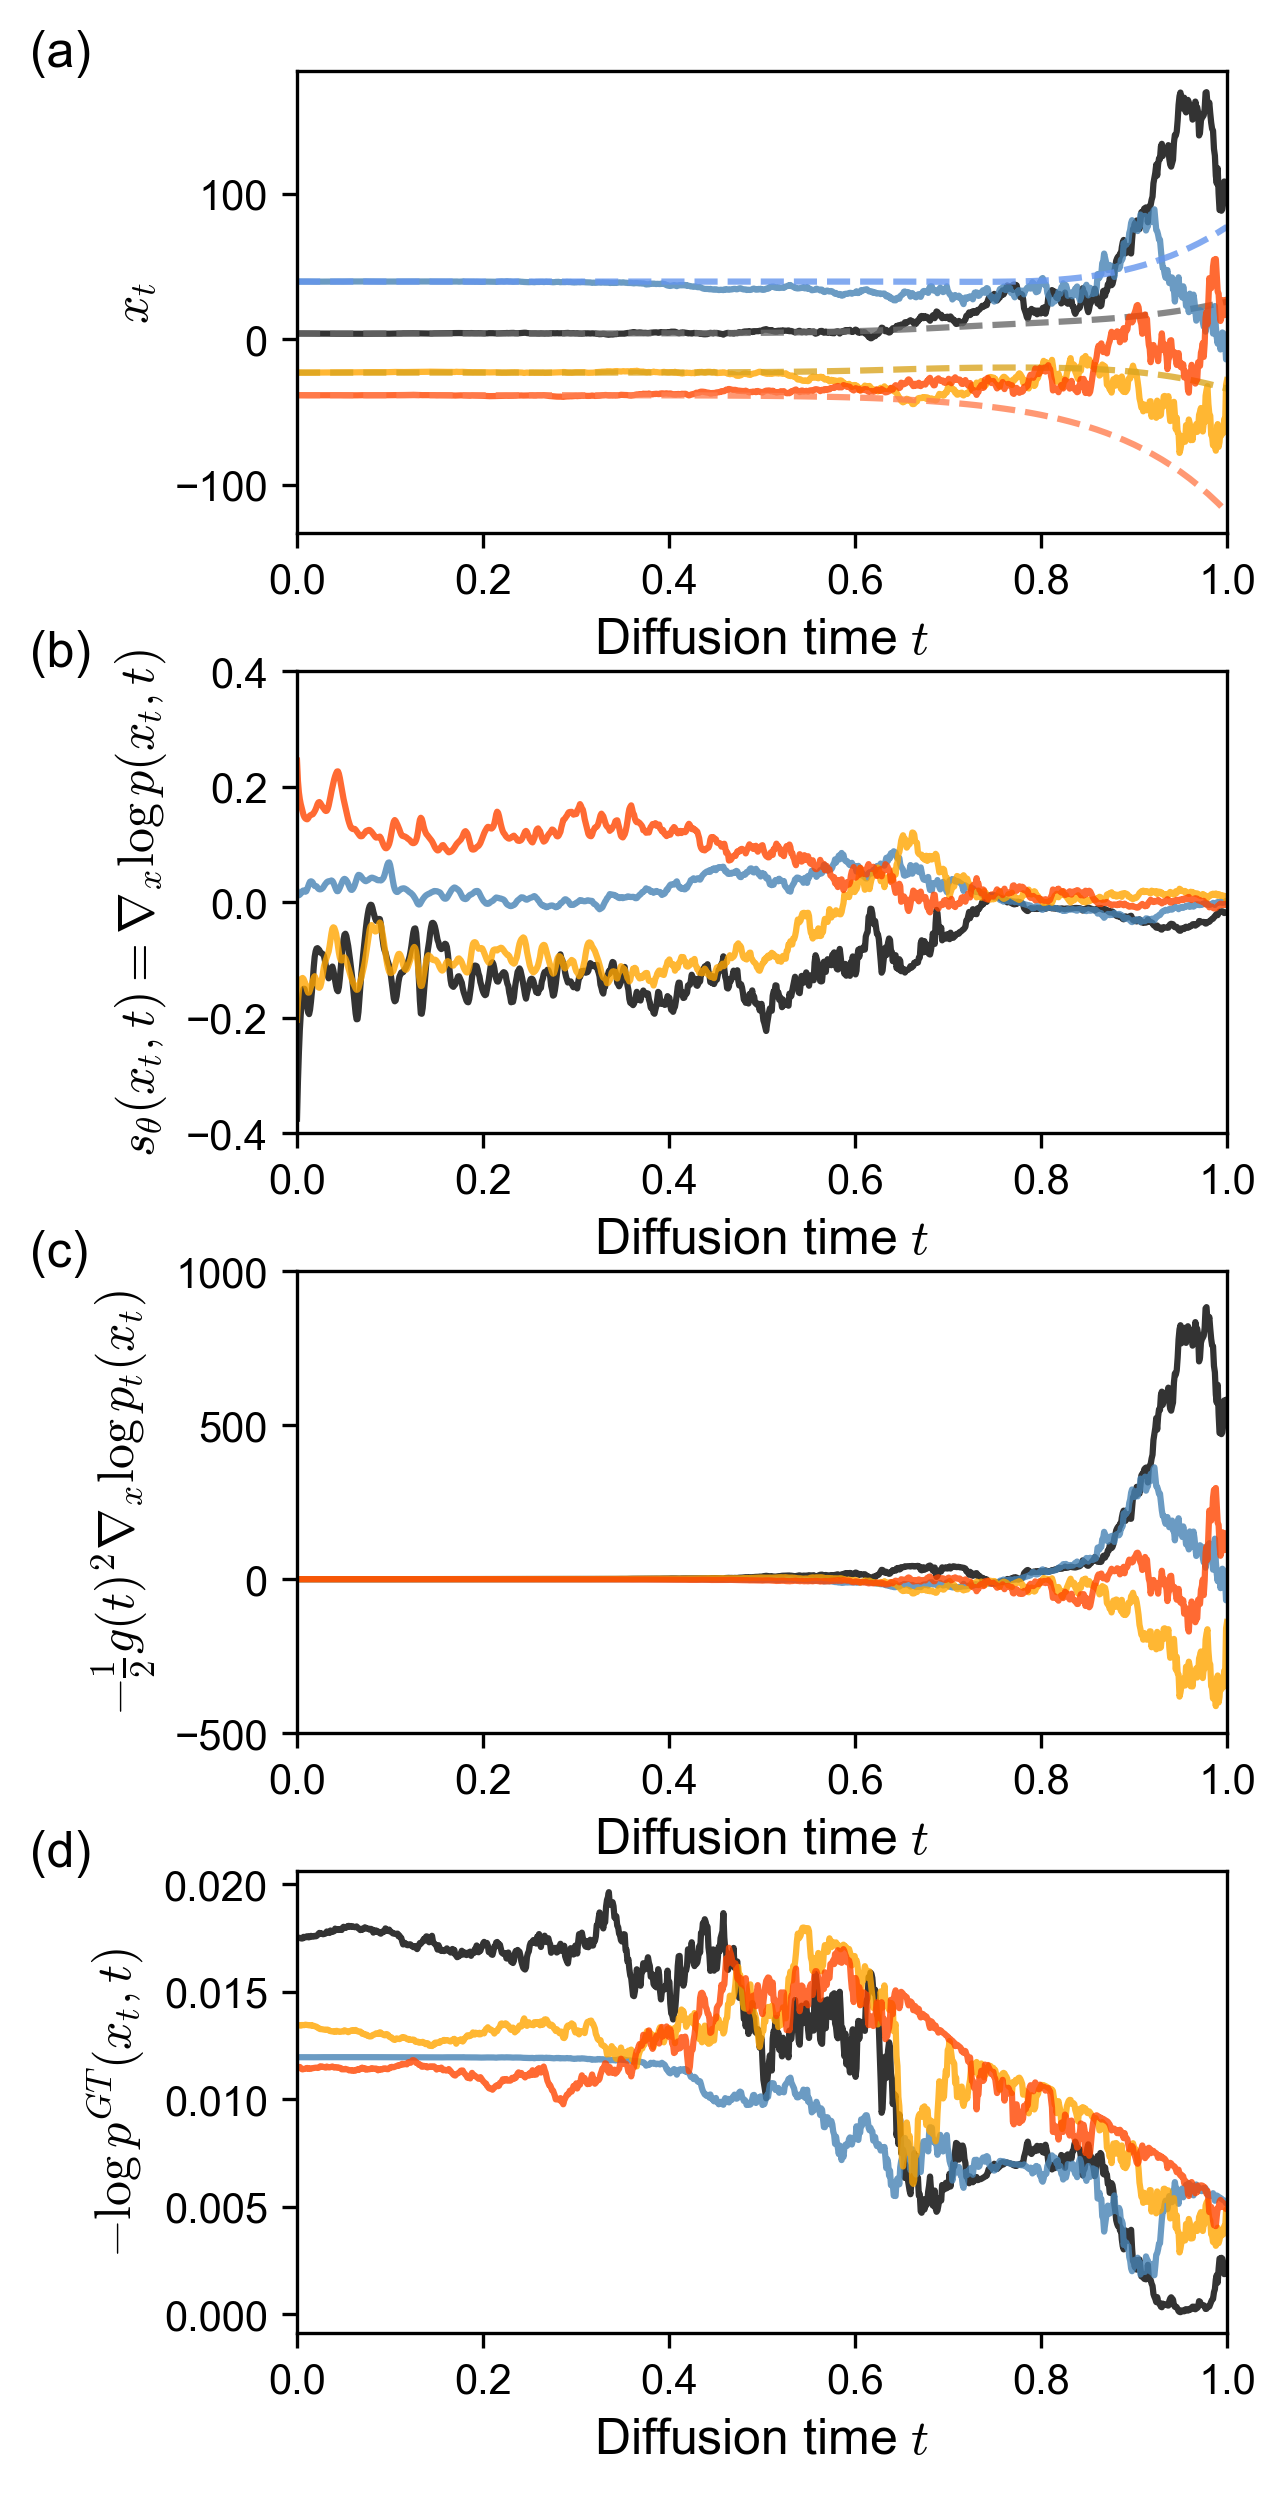

In [50]:
from typing import Any

from matplotlib.figure import SubFigure


plot_trajs = [94,16,22,73]
paircolors = [ #diff,flow
    ('black',     'dimgray',       ),
    ('steelblue', 'cornflowerblue',),
    ('orange',    'goldenrod',     ),
    ('orangered', 'coral',         ),
]
colors = [p[0] for p in paircolors]

f = plt.figure(figsize=(4.4,8))
f.tight_layout()
subs = f.subfigures(ncols=2,nrows=4,width_ratios=[0.1,1])
axes = [s[1].subplots() for s in subs]

def make_trajrow(ax,trajs,ylabel):
    ax.set_xlim(0,1)
    for traj,(diffcolor,flowcolor) in zip(plot_trajs,paircolors):
        diff = diff_trajectories[traj]
        flow = flow_trajectories[traj-1]
        ax.plot(diff[0],diff[1],color=diffcolor, alpha=0.8, label=f"Diff Trajectory {traj}")
        ax.plot(flow[0],flow[1],color=flowcolor, linestyle='--', alpha=0.8, label = f"Flow Trajectory {traj}")
    ax.set_xlabel('Diffusion time $t$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

def make_row(ax,plots:Iterable[tuple[Any,Any]],colors,ylabel):
    ax.set_xlim(0,1)
    for (t,val),color in zip(plots,colors):
        ax.plot(t,val,color=color, alpha=0.8)
    ax.set_xlabel('Diffusion time $t$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
make_trajrow(axes[0],plot_trajs,'$x_{t}$')

# plot x centered on its t0 point
# make_row(axes[1],[(diff_trajectories[i][0],diff_trajectories[i][1] - diff_trajectories[i][1][0]) for i in plot_trajs],colors,'$x_{t}-x_{0}$')


make_row(axes[1],[(difftraj_forces[id]['time'],difftraj_forces[id]['score']) for id in plot_trajs],
         colors,r'$s_{\theta} (x_t,t)=\nabla_{x} \log p(x_{t},t)$')
axes[1].set_ylim(-0.4,0.4)

make_row(axes[2],[(difftraj_forces[id]['time'],-1/2*(difftraj_forces[id]['diff_coeff']**2)*difftraj_forces[id]['score'][:,0]) for id in plot_trajs],
         colors,r'$-\frac{1}{2}g(t)^2 \nabla_{x} \log p_{t}(x_{t})$')
axes[2].set_ylim(-500,1000)

make_row(axes[3],[(diff_trajectories[traj][0],get_timed_gt_gaussian(diff_trajectories[traj][1],diff_trajectories[traj][0])) for traj in plot_trajs],
         colors,r'$-\log p^{GT}(x_t,t)$')

#add labels
for (s,_),label in zip(subs,("(a)","(b)","(c)","(d)")):
    assert isinstance(s,SubFigure)
    s.text(.025, .95, label, ha='left', va='top', transform=s.transSubfigure,fontdict={"fontsize":"large"})

# make_row(axes[2],[diff_trajectories[i] for i in plot_trajs],colors,'dum')

f.set_dpi(300)
f.savefig('diffenergy_paper/figure_2.png',dpi=300,bbox_inches='tight')

In [9]:
# Figure 4
from matplotlib.figure import Figure, SubFigure

#going to try using subfigures. Hope this works!
def add_comb_row(fig:SubFigure, parent_folder:Path, likelihood_subfolder:Path, integrand:str, prior:str, title:str, label:str, binline=False,):
    probax,corax = fig.subplots(nrows=1,ncols=2,width_ratios=[2,1.5])

    plot_sample_result(parent_folder,likelihood_subfolder,integrand,prior,binline=binline,ax=probax,save=False,fig_title=False,ax_title=False)
    r,pval = plot_correlation(parent_folder,likelihood_subfolder,integrand,prior,ax=corax,save=False,fig_title=False,ax_title=False)

    corax.text(.01,.75, f"$r_p={r:0.2f}$",ha='left',va='center',transform=corax.transAxes)

    fig.suptitle(title)
    #add subfigure label
    fig.text(.01, .99, label, ha='left', va='top', transform=fig.transSubfigure,fontdict={"fontsize":"large"})


#probability size: (3,2); correlation size: (1.5,1.5)
# Row size: (5.5,2.5)? extra .5 in width for spacing and .5 in height for titles
f = plt.figure(figsize=(5,6),layout='constrained')
subfs:list[SubFigure] = f.subfigures(nrows=3,wspace=0.5,squeeze=True)

f.set_dpi(300)

add_comb_row(subfs[0],likelihood_dir,Path('gaussian_1d/3integrand_diff'),'integrand:TotalIntegrand','prior:smax_gaussian','Diffusion Trajectory','(a)',binline=True)
add_comb_row(subfs[1],likelihood_dir,Path('gaussian_1d/3integrand_diff_10interp_1000'),'integrand:TotalIntegrand','prior:smax_gaussian','Diffusion Trajectory, 10x Interpolated','(b)',binline=True)
add_comb_row(subfs[2],likelihood_dir,Path('gaussian_1d/3integrand_flow'),'integrand:TotalIntegrand','prior:smax_gaussian','Flow Trajectory','(c)')

plt.savefig("diffenergy_paper/figure_3.png")

NameError: name 'likelihood_dir' is not defined

<Figure size 1500x1800 with 0 Axes>

In [ ]:
path = '/scratch4/jgray21/ssarma4/repos/DiffEnergy/src/exps/laplacian/data/traj/'

x_values = np.linspace(0, 1, 1000)

filename_1 = 'lp1.csv'
df1 = pd.read_csv(path+filename_1)
sample_values_1 = df1['Sample'].values[::-1]

filename_2 = 'lp2.csv'
df2 = pd.read_csv(path+filename_2)
sample_values_2 = df2['Sample'].values[::-1]

filename_3 = 'lp3.csv'
df3 = pd.read_csv(path+filename_3)
sample_values_3 = df3['Sample'].values[::-1]

filename_4 = 'lp4.csv'
df4 = pd.read_csv(path+filename_4)
sample_values_4 = df4['Sample'].values[::-1]

with open('/home/dxu39/scr4_jgray21/dxu39/projects/diffenergy/submit/sample_flow_path/sample_flow_path.pkl', 'rb') as f:
    sample_flow_path = pickle.load(f)

x_values_flow = np.linspace(0, 1, 100)

# Plot
plt.figure(figsize=(4, 1.8))
plt.plot(x_values, sample_values_1, color='black', alpha=0.8, label="Trajectory 1")
plt.plot(x_values, sample_values_2, color='steelblue', alpha=0.8, label="Trajectory 2")
plt.plot(x_values, sample_values_3, color='orange', alpha=0.8, label="Trajectory 3")
plt.plot(x_values, sample_values_4, color='orangered', alpha=0.8, label="Trajectory 4")
plt.plot(x_values_flow, sample_flow_path[0][:,0], color='dimgray', linestyle='--', alpha=0.8, label="Trajectory 1")
plt.plot(x_values_flow, sample_flow_path[1][:,0], color='cornflowerblue', linestyle='--', alpha=0.8, label="Trajectory 2")
plt.plot(x_values_flow, sample_flow_path[2][:,0], color='goldenrod', linestyle='--', alpha=0.8, label="Trajectory 3")
plt.plot(x_values_flow, sample_flow_path[3][:,0], color='coral', linestyle='--', alpha=0.8, label="Trajectory 4")
# plt.xticks([0, 1000], labels=['0', '1'])
# plt.yticks(fontsize=16)
plt.xlim(0, 1)
# plt.legend()
plt.xlabel('Diffusion time $t$', fontsize=12)
plt.ylabel('$x_{t}$', fontsize=12)
plt.gcf().set_dpi(300)
plt.savefig('sample_v_t.png', dpi=300, bbox_inches='tight')